# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


Сигнал | Среднее | Дисперсия
White  |  0.04508 |  0.97658
Pink   |  0.00000 |  1.00000
Red    |  0.00000 |  1.00000


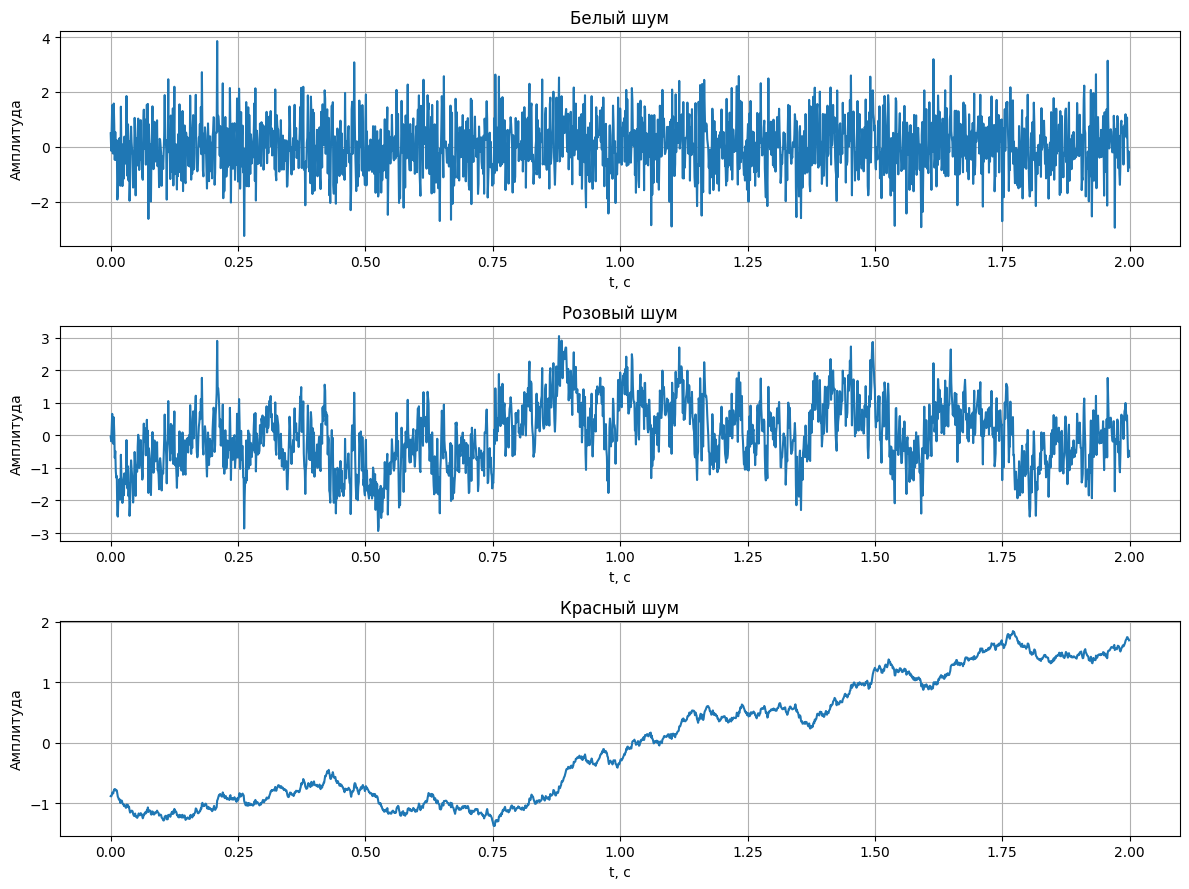

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Параметры
fs = 1000
T = 2.0
N = int(fs * T)
t = np.arange(N) / fs

# Белый шум: среднее 0, дисперсия 1
white_noise = np.random.normal(0, 1, N)

# Розовый шум: FFT -> умножение на 1/sqrt(f) -> IFFT -> нормализация
X_white = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(N, d=1/fs)

pink_filter = np.ones_like(freqs)
pink_filter[1:] = 1 / np.sqrt(freqs[1:])   # избегаем деления на ноль
pink_filter[0] = 0

X_pink = X_white * pink_filter
pink_noise = np.fft.irfft(X_pink, n=N)
pink_noise = pink_noise - np.mean(pink_noise)
pink_noise = pink_noise / np.std(pink_noise)

# Красный шум: кумулятивная сумма белого -> нормализация
red_noise = np.cumsum(white_noise)
red_noise = red_noise - np.mean(red_noise)
red_noise = red_noise / np.std(red_noise)

# Средние и дисперсии
signals = {
    "White": white_noise,
    "Pink": pink_noise,
    "Red": red_noise
}

print("Сигнал | Среднее | Дисперсия")
for name, sig in signals.items():
    print(f"{name:6s} | {np.mean(sig): .5f} | {np.var(sig): .5f}")

# Графики
plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.plot(t, white_noise)
plt.title("Белый шум")
plt.xlabel("t, c")
plt.ylabel("Амплитуда")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, pink_noise)
plt.title("Розовый шум")
plt.xlabel("t, c")
plt.ylabel("Амплитуда")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, red_noise)
plt.title("Красный шум")
plt.xlabel("t, c")
plt.ylabel("Амплитуда")
plt.grid()

plt.tight_layout()
plt.show()

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


**Ответ:** Белый шум выглядит как быстрые хаотические колебания, розовый — более плавный, а красный — самый сглаженный и медленно меняющийся. Средние значения близки к нулю, дисперсии — к 1. Небольшие отклонения у белого шума связаны со случайностью и конечной длиной сигнала, а для розового и красного шума значения почти точно совпадают из-за последующей нормализации.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


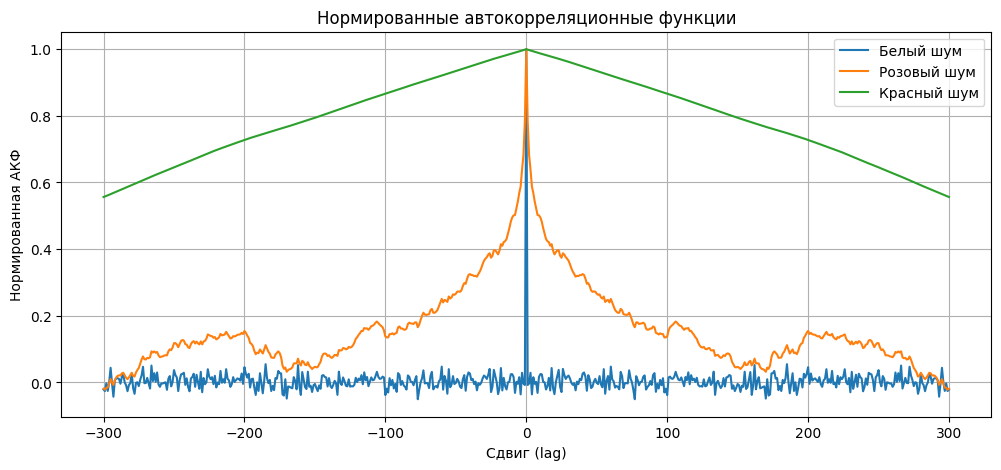

In [2]:
np.random.seed(42)

# Параметры
fs = 1000
T = 2.0
N = int(fs * T)

def normalized_acf(x):
    acf = np.correlate(x, x, mode='full')
    acf = acf / acf[len(x) - 1]   # нормировка на значение при нулевом сдвиге
    lags = np.arange(-len(x) + 1, len(x))
    return lags, acf

lags_w, acf_w = normalized_acf(white_noise)
lags_p, acf_p = normalized_acf(pink_noise)
lags_r, acf_r = normalized_acf(red_noise)

# Для наглядности покажем центральную симметричную часть
max_lag = 300
mask_w = np.abs(lags_w) <= max_lag
mask_p = np.abs(lags_p) <= max_lag
mask_r = np.abs(lags_r) <= max_lag

plt.figure(figsize=(12, 5))
plt.plot(lags_w[mask_w], acf_w[mask_w], label='Белый шум')
plt.plot(lags_p[mask_p], acf_p[mask_p], label='Розовый шум')
plt.plot(lags_r[mask_r], acf_r[mask_r], label='Красный шум')
plt.title('Нормированные автокорреляционные функции')
plt.xlabel('Сдвиг (lag)')
plt.ylabel('Нормированная АКФ')
plt.grid()
plt.legend()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


**Ответ:** Чем более гладкий шум, тем шире и медленнее спадает его АКФ. У белого шума АКФ почти сразу падает к нулю, поэтому сигнал выглядит самым резким и хаотичным. У розового шума АКФ шире, значит соседние отсчёты сильнее связаны и сигнал более плавный. У красного шума АКФ самая широкая, что соответствует наиболее сглаженному и медленно меняющемуся сигналу.


## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


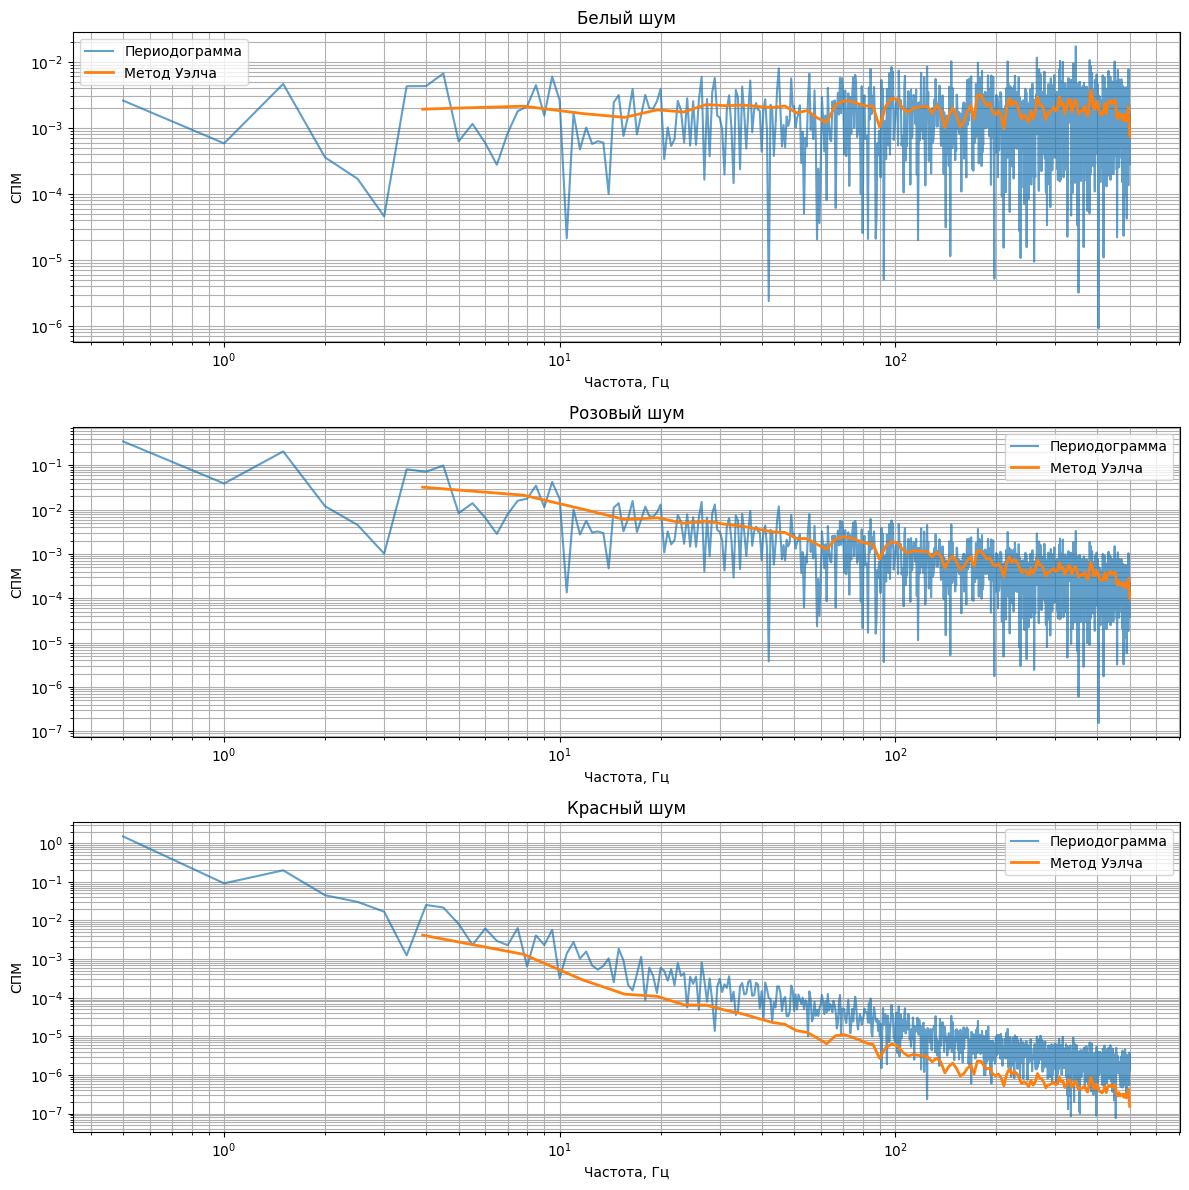

In [5]:
from scipy.signal import periodogram, welch

np.random.seed(42)

# СПМ: периодограмма и метод Уэлча
plt.figure(figsize=(12, 12))

for i, (name, sig) in enumerate(signals.items(), 1):
    f_per, Pxx_per = periodogram(sig, fs=fs)
    f_welch, Pxx_welch = welch(sig, fs=fs, nperseg=256, noverlap=128, window='hann')

    # Убираем нулевую частоту для loglog
    plt.subplot(3, 1, i)
    plt.loglog(f_per[1:], Pxx_per[1:], label='Периодограмма', alpha=0.7)
    plt.loglog(f_welch[1:], Pxx_welch[1:], label='Метод Уэлча', linewidth=2)
    plt.title(name)
    plt.xlabel('Частота, Гц')
    plt.ylabel('СПМ')
    plt.grid(True, which='both')
    plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


**Ответ:** В двойном логарифмическом масштабе СПМ белого шума почти горизонтальна, у розового она убывает примерно как прямая с наклоном `-1`, а у красного — ещё круче, примерно с наклоном `-2`. Теоретически это соответствует зависимостям `S(f) ∼ const`, `S(f) ∼ 1/f` и `S(f) ∼ 1/f^2`. Периодограмма получается более шумной, а оценка методом Уэлча — более гладкой, но общий характер зависимости сохраняется.


## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


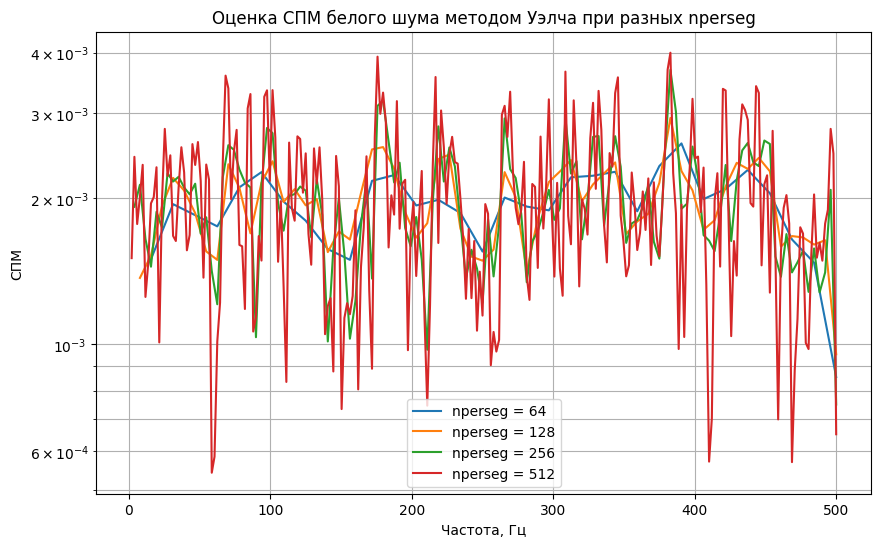

In [6]:
# Длины сегмента
nperseg_values = [64, 128, 256, 512]

plt.figure(figsize=(10, 6))

for nperseg in nperseg_values:
    f, Pxx = welch(
        white_noise,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2
    )
    plt.semilogy(f[1:], Pxx[1:], label=f'nperseg = {nperseg}')

plt.title('Оценка СПМ белого шума методом Уэлча при разных nperseg')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


**Ответ:** При увеличении длины сегмента `nperseg` улучшается частотное разрешение - спектральные детали различаются точнее, а пики становятся уже. Но при этом оценка СПМ становится менее гладкой и более шумной, потому что усреднение идёт по меньшему числу сегментов. При меньшем `nperseg` наоборот: оценка более сглаженная, но частотное разрешение хуже.

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

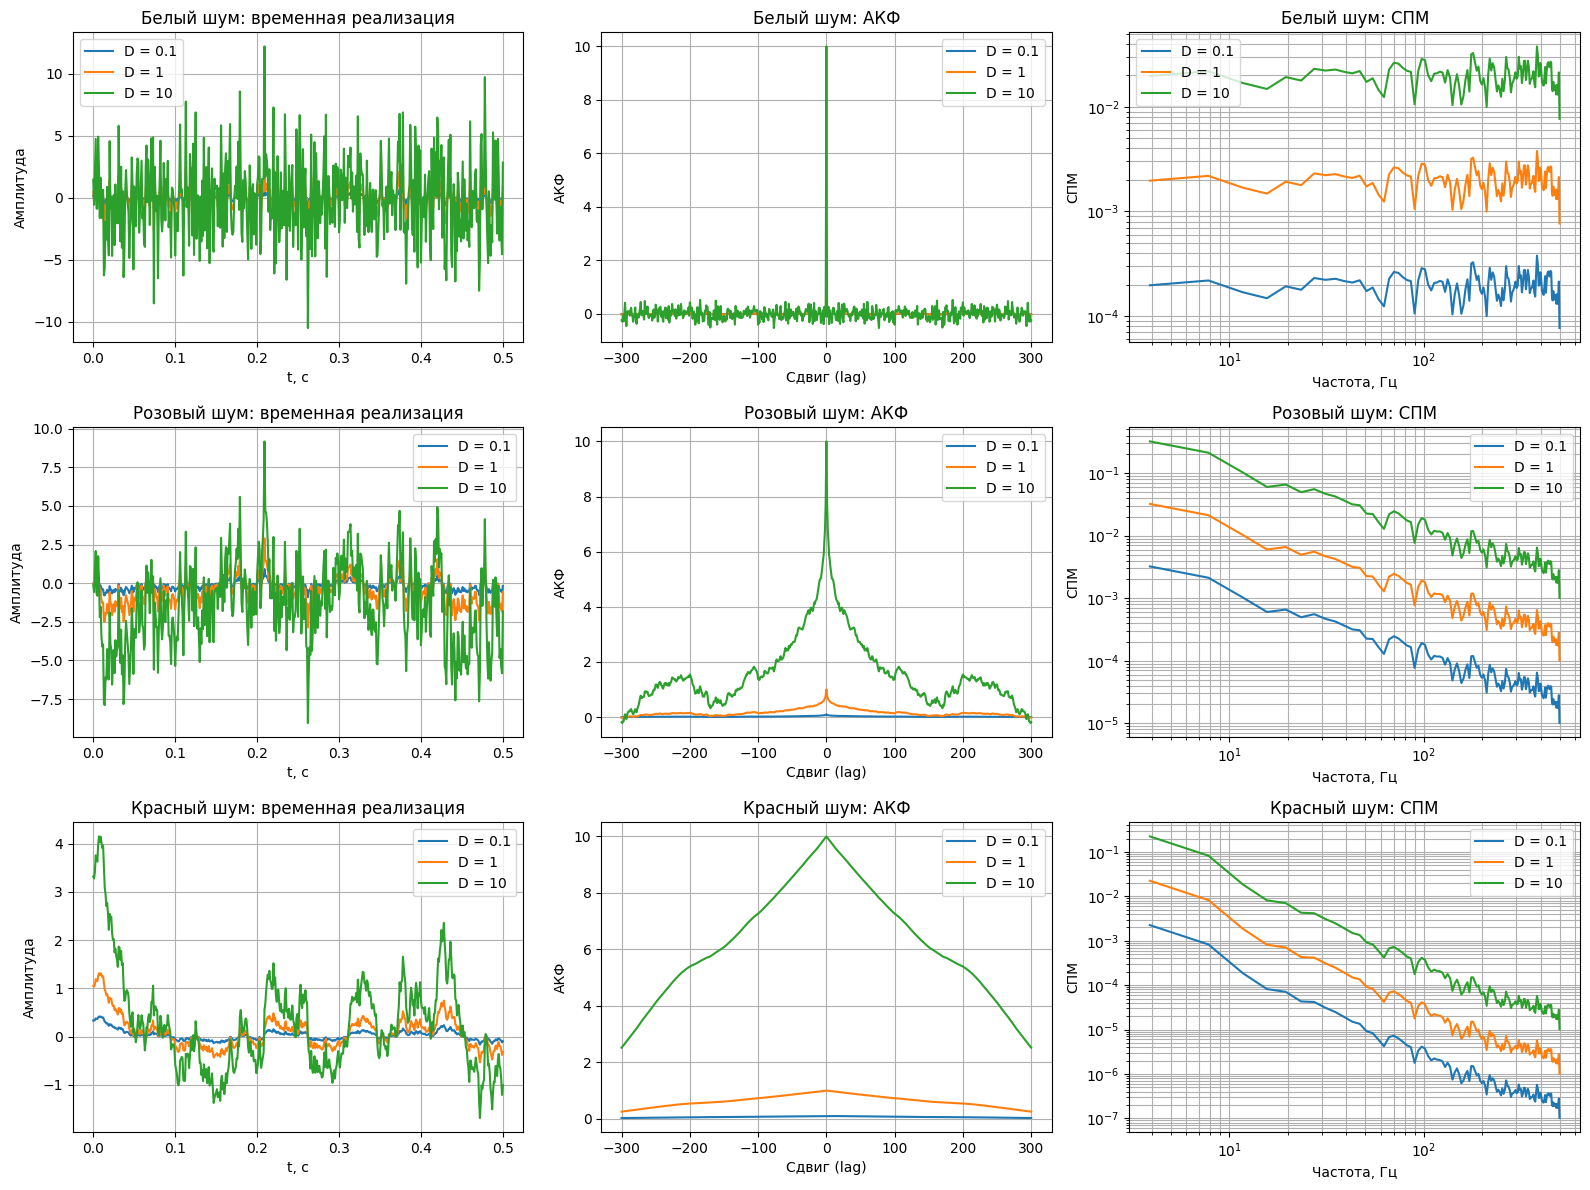

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

np.random.seed(42)

# Параметры
fs = 1000
T = 2.0
N = int(fs * T)
t = np.arange(N) / fs
variances = [0.1, 1, 10]

# Белый
base_white = np.random.normal(0, 1, N)
base_white = (base_white - np.mean(base_white)) / np.std(base_white)

# Розовый
X_white = np.fft.rfft(base_white)
freqs = np.fft.rfftfreq(N, d=1/fs)

pink_filter = np.ones_like(freqs)
pink_filter[1:] = 1 / np.sqrt(freqs[1:])
pink_filter[0] = 0

X_pink = X_white * pink_filter
base_pink = np.fft.irfft(X_pink, n=N)
base_pink = (base_pink - np.mean(base_pink)) / np.std(base_pink)

# Красный
base_red = np.cumsum(base_white)
base_red = (base_red - np.mean(base_red)) / np.std(base_red)

bases = {
    "Белый шум": base_white,
    "Розовый шум": base_pink,
    "Красный шум": base_red
}

def acf_raw(x, max_lag=300):
    acf = np.correlate(x, x, mode='full') / len(x)
    lags = np.arange(-len(x) + 1, len(x))
    mask = np.abs(lags) <= max_lag
    return lags[mask], acf[mask]

# Графики
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row, (name, base_signal) in enumerate(bases.items()):
    for var in variances:
        x = base_signal * np.sqrt(var)

        # 1. Временная реализация
        mask_t = t <= 0.5
        axes[row, 0].plot(t[mask_t], x[mask_t], label=f'D = {var}')

        # 2. АКФ
        lags, acf_vals = acf_raw(x, max_lag=300)
        axes[row, 1].plot(lags, acf_vals, label=f'D = {var}')

        # 3. СПМ
        f, Pxx = welch(x, fs=fs, nperseg=256, noverlap=128, window='hann')
        axes[row, 2].loglog(f[1:], Pxx[1:], label=f'D = {var}')

    axes[row, 0].set_title(f'{name}: временная реализация')
    axes[row, 0].set_xlabel('t, c')
    axes[row, 0].set_ylabel('Амплитуда')
    axes[row, 0].grid()

    axes[row, 1].set_title(f'{name}: АКФ')
    axes[row, 1].set_xlabel('Сдвиг (lag)')
    axes[row, 1].set_ylabel('АКФ')
    axes[row, 1].grid()

    axes[row, 2].set_title(f'{name}: СПМ')
    axes[row, 2].set_xlabel('Частота, Гц')
    axes[row, 2].set_ylabel('СПМ')
    axes[row, 2].grid(True, which='both')

    for col in range(3):
        axes[row, col].legend()

plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


**Ответ:** При увеличении дисперсии шум становится сильнее по амплитуде: во временной области растёт разброс значений. У АКФ увеличивается общий уровень, но её форма для каждого типа шума почти не меняется. СПМ тоже поднимается вверх примерно пропорционально дисперсии, при этом её характер сохраняется: у белого шума она почти плоская, у розового убывает как `1/f`, у красного — как `1/f^2`.

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


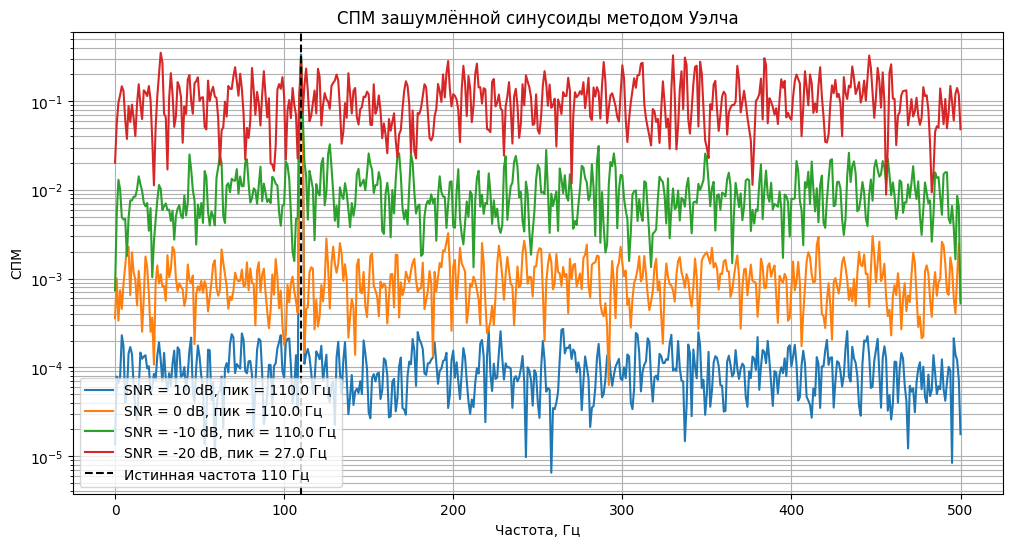

SNR (dB) | Частота пика (Гц) | Ошибка (Гц)
      10 |             110.0 |        0.0
       0 |             110.0 |        0.0
     -10 |             110.0 |        0.0
     -20 |              27.0 |       83.0


In [9]:
np.random.seed(42)

# Параметры сигнала
f0 = 110
A = 1.0
signal_clean = A * np.sin(2 * np.pi * f0 * t)

# Мощность синусоиды
P_sig = A**2 / 2

# Набор SNR для сравнения
snr_db_values = [10, 0, -10, -20]

# Выбираем nperseg так, чтобы 110 Гц хорошо разрешалась
nperseg = 1000   # частотный шаг ~ 1 Гц
noverlap = nperseg // 2

plt.figure(figsize=(12, 6))
results = []

for snr_db in snr_db_values:
    snr_lin = 10**(snr_db / 10)
    P_noise = P_sig / snr_lin
    sigma_noise = np.sqrt(P_noise)

    noise = np.random.normal(0, sigma_noise, N)
    x = signal_clean + noise

    f, Pxx = welch(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap
    )

    peak_idx = np.argmax(Pxx)
    peak_freq = f[peak_idx]
    results.append((snr_db, peak_freq))

    plt.semilogy(f, Pxx, label=f'SNR = {snr_db} dB, пик = {peak_freq:.1f} Гц')

plt.axvline(f0, color='k', linestyle='--', label='Истинная частота 110 Гц')
plt.title('СПМ зашумлённой синусоиды методом Уэлча')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()
plt.show()

print("SNR (dB) | Частота пика (Гц) | Ошибка (Гц)")
for snr_db, peak_freq in results:
    print(f"{snr_db:8d} | {peak_freq:17.1f} | {abs(peak_freq - f0):10.1f}")

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


**Ответ:** При уменьшении SNR пик на `110 Гц` становится всё менее заметным и сильнее маскируется шумовым фоном. По вашим результатам он уверенно виден и правильно определяется при `10`, `0` и `-10 дБ`, а при `-20 дБ` уже теряется: максимум смещается на другую частоту. Значит, в данном эксперименте пик ещё можно уверенно обнаружить визуально примерно до `-10 дБ`.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


nperseg | Δf ≈ fs/nperseg | найденные пики (Гц)
    128 |           7.81 |  109.4
    256 |           3.91 |  101.6,  109.4
    512 |           1.95 |   99.6,  109.4


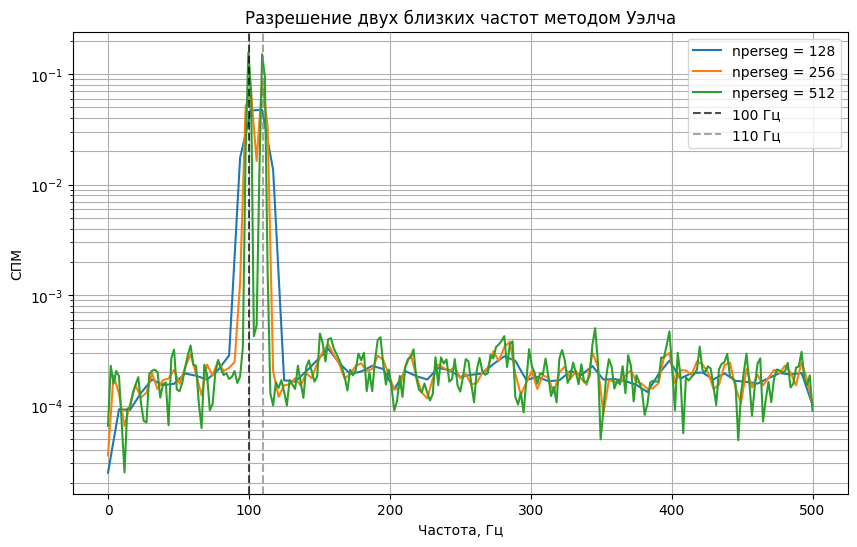

In [10]:
from scipy.signal import find_peaks

# Сигнал: две близкие частоты + белый шум с дисперсией 0.1
x = (
    np.sin(2 * np.pi * 100 * t) +
    np.sin(2 * np.pi * 110 * t) +
    np.random.normal(0, np.sqrt(0.1), N)
)

nperseg_values = [128, 256, 512]

plt.figure(figsize=(10, 6))

print("nperseg | Δf ≈ fs/nperseg | найденные пики (Гц)")

for nperseg in nperseg_values:
    f, Pxx = welch(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2
    )

    plt.semilogy(f, Pxx, label=f'nperseg = {nperseg}')

    # Ищем пики в области интереса
    mask = (f >= 80) & (f <= 130)
    f_band = f[mask]
    P_band = Pxx[mask]

    peaks, _ = find_peaks(P_band)
    if len(peaks) >= 2:
        top2 = peaks[np.argsort(P_band[peaks])[-2:]]
        peak_freqs = np.sort(f_band[top2])
        print(f"{nperseg:7d} | {fs/nperseg:14.2f} | {peak_freqs[0]:6.1f}, {peak_freqs[1]:6.1f}")
    elif len(peaks) == 1:
        print(f"{nperseg:7d} | {fs/nperseg:14.2f} | {f_band[peaks[0]]:6.1f}")
    else:
        print(f"{nperseg:7d} | {fs/nperseg:14.2f} | пиков не найдено")

plt.axvline(100, color='k', linestyle='--', alpha=0.7, label='100 Гц')
plt.axvline(110, color='gray', linestyle='--', alpha=0.7, label='110 Гц')
plt.title('Разрешение двух близких частот методом Уэлча')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


**Ответ:** По полученным результатам две частоты начинают разделяться уже при `nperseg = 256`, а наиболее чётко — при `nperseg = 512`. При `nperseg = 128` виден только один общий пик около 109.4 Гц. Это согласуется с оценкой $\Delta f \approx f_s/N_{seg}$: для 128 получаем $\approx 7.8$ Гц, для 256 — $\approx 3.9$ Гц, для 512 — $\approx 2.0$ Гц. Так как расстояние между частотами равно 10 Гц, при 256 и особенно при 512 разрешения уже достаточно для их разделения.